# Applied Exercise 8 - Forward/Backward Stepwise Selection and Lasso

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ISLP import load_data

from sklearn.linear_model import LinearRegression, Lasso, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline, Pipeline
from itertools import combinations
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

In [14]:
rng = np.random.default_rng(1)
n = 100

X = rng.normal(size=n)
eps = rng.normal(size=n)

# Y = 3 + 2X - 1.5X^2 + 0.5X^3 + epsilon
beta0 = 3
beta1 = 2
beta2 = -1.5
beta3 = 0.5
Y = beta0 + beta1*X + beta2*X**2 + beta3*X**3 + eps

print("\nData Generation")
print("-" * 70)
print(f"n = {n}")
print("True model:")
print("Y = 3 + 2X - 1.5X^2 + 0.5X^3 + epsilon")


Data Generation
----------------------------------------------------------------------
n = 100
True model:
Y = 3 + 2X - 1.5X^2 + 0.5X^3 + epsilon


In [15]:
X_poly = np.column_stack([X**j for j in range(1, 11)])
feature_names = [f"X^{j}" for j in range(1, 11)]

def calculate_cp(X_subset, y, rss, p, sigma2):
    n = len(y)
    return rss / sigma2 - (n - 2 * p)

full_model = LinearRegression().fit(X_poly, Y)
full_pred = full_model.predict(X_poly)
full_rss = np.sum((Y - full_pred)**2)
sigma2 = full_rss / (n - 11)

In [16]:
remaining = list(range(10))
selected_forward = []
forward_results = []

while len(remaining) > 0:
    candidates = []

    for candidate in remaining:
        current = selected_forward + [candidate]

        model = LinearRegression().fit(X_poly[:, current], Y)
        pred = model.predict(X_poly[:, current])
        rss = np.sum((Y - pred)**2)
        p = len(current) + 1

        cp = calculate_cp(X_poly[:, current], Y, rss, p, sigma2)
        candidates.append((cp, candidate, current))

    best_cp, best_candidate, best_model_vars = min(candidates, key=lambda x: x[0])

    selected_forward.append(best_candidate)
    remaining.remove(best_candidate)

    forward_results.append({"Number of Variables": len(selected_forward), "Variables": [feature_names[i] for i in selected_forward], "Cp": best_cp})

forward_df = pd.DataFrame(forward_results)
best_forward_row = forward_df.loc[forward_df["Cp"].idxmin()]
best_forward_vars = selected_forward[:best_forward_row["Number of Variables"]]

forward_model = LinearRegression().fit(X_poly[:, best_forward_vars], Y)

print("\nForward Stepwise Selection")
print("-" * 70)
print(forward_df[["Number of Variables", "Variables", "Cp"]])

print("\nBest model according to Cp:")
print(best_forward_row["Variables"])
print(f"Cp = {best_forward_row['Cp']:.4f}")

print("\nCoefficients:")
print(f"Intercept = {forward_model.intercept_:.4f}")

for name, coef in zip([feature_names[i] for i in best_forward_vars], forward_model.coef_):
    print(f"{name}: {coef:.4f}")


Forward Stepwise Selection
----------------------------------------------------------------------
   Number of Variables                                          Variables  \
0                    1                                              [X^3]   
1                    2                                         [X^3, X^2]   
2                    3                                    [X^3, X^2, X^1]   
3                    4                              [X^3, X^2, X^1, X^10]   
4                    5                         [X^3, X^2, X^1, X^10, X^4]   
5                    6                    [X^3, X^2, X^1, X^10, X^4, X^5]   
6                    7               [X^3, X^2, X^1, X^10, X^4, X^5, X^8]   
7                    8          [X^3, X^2, X^1, X^10, X^4, X^5, X^8, X^9]   
8                    9     [X^3, X^2, X^1, X^10, X^4, X^5, X^8, X^9, X^7]   
9                   10  [X^3, X^2, X^1, X^10, X^4, X^5, X^8, X^9, X^7,...   

           Cp  
0  380.829445  
1  146.857804  
2   1

The important point is that forward selection correctly identified the three important predictors X, X^2, X^3 from the true model. It also included X^10, which was not part of the true model. This can happen because the procedure is selecting variables based on the particular simulated sample.

In [17]:
selected_backward = list(range(10))
backward_results = []

while len(selected_backward) > 0:
    model = LinearRegression().fit(X_poly[:, selected_backward], Y)
    pred = model.predict(X_poly[:, selected_backward])
    rss = np.sum((Y - pred)**2)

    p = len(selected_backward) + 1
    cp = calculate_cp(X_poly[:, selected_backward], Y, rss, p, sigma2)

    backward_results.append({"Number of Variables": len(selected_backward), "Variables": [feature_names[i] for i in selected_backward], "Cp": cp})
    if len(selected_backward) == 1:
        break

    candidates = []
    for candidate in selected_backward:
        current = [i for i in selected_backward if i != candidate]
        model = LinearRegression().fit(X_poly[:, current], Y)
        pred = model.predict(X_poly[:, current])
        rss = np.sum((Y - pred)**2)

        p = len(current) + 1
        cp = calculate_cp(X_poly[:, current], Y, rss, p, sigma2)
        candidates.append((cp, current))

    best_cp, best_current = min(candidates, key=lambda x: x[0])
    selected_backward = best_current

backward_df = pd.DataFrame(backward_results)
best_backward_row = backward_df.loc[backward_df["Cp"].idxmin()]
best_backward_vars = [feature_names.index(name) for name in best_backward_row["Variables"]]
backward_model = LinearRegression().fit(X_poly[:, best_backward_vars], Y)

print("\nBackward Stepwise Selection")
print("-" * 70)
print(backward_df[["Number of Variables", "Variables", "Cp"]])

print("\nBest model according to Cp:")
print(best_backward_row["Variables"])
print(f"Cp = {best_backward_row['Cp']:.4f}")

print("\nCoefficients:")
print(f"Intercept = {backward_model.intercept_:.4f}")

for name, coef in zip([feature_names[i] for i in best_backward_vars], backward_model.coef_):
    print(f"{name}: {coef:.4f}")


Backward Stepwise Selection
----------------------------------------------------------------------
   Number of Variables                                          Variables  \
0                   10  [X^1, X^2, X^3, X^4, X^5, X^6, X^7, X^8, X^9, ...   
1                    9     [X^1, X^2, X^3, X^5, X^6, X^7, X^8, X^9, X^10]   
2                    8          [X^1, X^2, X^5, X^6, X^7, X^8, X^9, X^10]   
3                    7               [X^1, X^2, X^6, X^7, X^8, X^9, X^10]   
4                    6                    [X^1, X^2, X^6, X^7, X^8, X^10]   
5                    5                          [X^1, X^2, X^6, X^7, X^8]   
6                    4                               [X^1, X^2, X^7, X^8]   
7                    3                                    [X^1, X^2, X^7]   
8                    2                                         [X^1, X^2]   
9                    1                                              [X^1]   

           Cp  
0   11.000000  
1    9.443117  
2   

The results are not exactly the same as forward selection. This also demonstrates that stepwise selection does not necessarily recover the exact true model, even when the true model is relatively simple.

In [18]:
alphas = np.logspace(-4, 2, 200)
cv = KFold(n_splits=10, shuffle=True, random_state=1)

lasso_cv = make_pipeline(StandardScaler(), LassoCV(alphas=alphas, cv=cv, max_iter=100000))
lasso_cv.fit(X_poly, Y)
lasso = lasso_cv.named_steps["lassocv"]
best_alpha = lasso.alpha_
lasso_coefs = lasso.coef_

print("\nLasso Regression")
print("-" * 70)
print(f"Optimal lambda (alpha) = {best_alpha:.6f}")

print("\nLasso coefficients:")
print(f"Intercept = {lasso_cv.predict(np.zeros((1, 10)))[0]:.4f}")
for name, coef in zip(feature_names, lasso_coefs):
    print(f"{name}: {coef:.4f}")


Lasso Regression
----------------------------------------------------------------------
Optimal lambda (alpha) = 0.000803

Lasso coefficients:
Intercept = 2.9803
X^1: 1.7284
X^2: -1.6941
X^3: 0.6919
X^4: -1.1352
X^5: 1.2943
X^6: 0.0000
X^7: -0.0000
X^8: 1.7983
X^9: -0.0000
X^10: 0.0000


Lasso does not necessarily recover the exact three-term polynomial that generated the data. The most important observation is that the Lasso estimates for the first three terms are reasonably close to the true values.

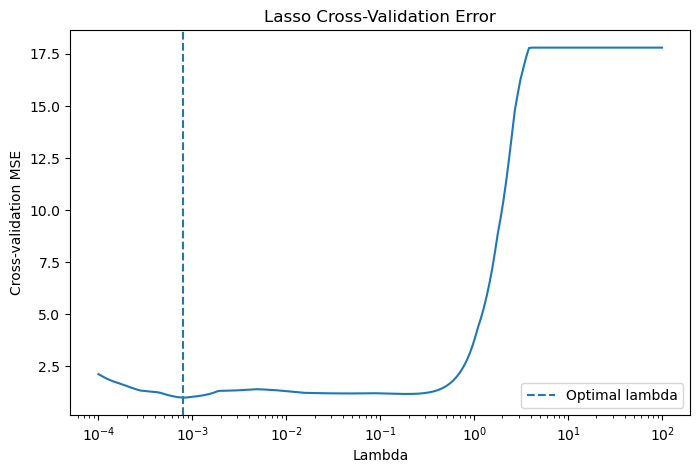

In [19]:
mean_mse = np.mean(lasso.mse_path_, axis=1)

plt.figure(figsize=(8, 5))
plt.plot(lasso.alphas_, mean_mse)
plt.axvline(best_alpha, linestyle="--", label="Optimal lambda")

plt.xscale("log")
plt.xlabel("Lambda")
plt.ylabel("Cross-validation MSE")
plt.title("Lasso Cross-Validation Error")
plt.legend()
plt.show()

In [20]:
# New model: Y = beta0 + beta7 X^7 + epsilon
Y2 = 3 + 2*X**7 + eps

remaining = list(range(10))
selected = []
forward2_results = []

while len(remaining) > 0:
    candidates = []

    for candidate in remaining:
        current = selected + [candidate]
        model = LinearRegression().fit(X_poly[:, current], Y2)

        pred = model.predict(X_poly[:, current])
        rss = np.sum((Y2 - pred)**2)
        p = len(current) + 1
        cp = calculate_cp(X_poly[:, current], Y2, rss, p, sigma2)
        candidates.append((cp, candidate, current))

    best_cp, best_candidate, best_current = min( candidates, key=lambda x: x[0])
    selected.append(best_candidate)
    remaining.remove(best_candidate)
    forward2_results.append({"Number of Variables": len(selected), "Variables": [feature_names[i] for i in selected], "Cp": best_cp})

forward2_df = pd.DataFrame(forward2_results)
best_forward2 = forward2_df.loc[forward2_df["Cp"].idxmin()]
best_forward2_vars = [feature_names.index(name) for name in best_forward2["Variables"]]
forward2_model = LinearRegression().fit(X_poly[:, best_forward2_vars], Y2)

print("\nNew Model: Y = 3 + 2X^7 + epsilon")
print("-" * 70)

print("\nForward Stepwise Selection:")
print(forward2_df)
print("\nBest Forward Model:")
print(best_forward2["Variables"])
print(f"Cp = {best_forward2['Cp']:.4f}")

print("\nCoefficients:")
print(f"Intercept = {forward2_model.intercept_:.4f}")
for name, coef in zip([feature_names[i] for i in best_forward2_vars], forward2_model.coef_):
    print(f"{name}: {coef:.4f}")


New Model: Y = 3 + 2X^7 + epsilon
----------------------------------------------------------------------

Forward Stepwise Selection:
   Number of Variables                                          Variables  \
0                    1                                              [X^7]   
1                    2                                         [X^7, X^9]   
2                    3                                    [X^7, X^9, X^4]   
3                    4                               [X^7, X^9, X^4, X^1]   
4                    5                          [X^7, X^9, X^4, X^1, X^8]   
5                    6                     [X^7, X^9, X^4, X^1, X^8, X^3]   
6                    7               [X^7, X^9, X^4, X^1, X^8, X^3, X^10]   
7                    8          [X^7, X^9, X^4, X^1, X^8, X^3, X^10, X^6]   
8                    9     [X^7, X^9, X^4, X^1, X^8, X^3, X^10, X^6, X^5]   
9                   10  [X^7, X^9, X^4, X^1, X^8, X^3, X^10, X^6, X^5,...   

          Cp  
0 

For the new model, forward stepwise selection correctly identified X^7 as the dominant predictor and estimated its coefficient as approximately 2.0162, extremely close to the true value of 2. The additional X^9 and X^4 terms have coefficients very close to zero, so their practical contribution is negligible.

In [21]:
lasso_cv2 = make_pipeline(StandardScaler(), LassoCV( alphas=alphas, cv=cv, max_iter=100000))
lasso_cv2.fit(X_poly, Y2)
lasso2 = lasso_cv2.named_steps["lassocv"]

print("\nLasso for New Model:")
print(f"Optimal lambda = {lasso2.alpha_:.6f}")
print("\nLasso coefficients:")
for name, coef in zip(feature_names, lasso2.coef_):
    print(f"{name}: {coef:.4f}")


Lasso for New Model:
Optimal lambda = 0.000247

Lasso coefficients:
X^1: 3.0407
X^2: -2.0530
X^3: -28.0065
X^4: 10.5294
X^5: 107.1860
X^6: -7.9468
X^7: 83.0429
X^8: -5.8603
X^9: 54.5534
X^10: -3.1346


The Lasso estimates in this second experiment are highly unstable, largely because X, X^2, …, X^10 are strongly correlated. Hence, these coefficients are clearly unstable and should not be interpreted as a meaningful recovery of the true model.

# Applied Exercise 9 - Predicting College Applications

In [8]:
College = load_data('College')

if College.columns[0] == "Unnamed: 0":
    College = College.set_index(College.columns[0])
if "Private" in College.columns and not pd.api.types.is_numeric_dtype(College["Private"]):
    College["Private"] = College["Private"].map({"Yes": 1, "No": 0})

y = College["Apps"]
X = College.drop(columns=["Apps"])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print("=" * 60)
print("TRAIN / TEST SPLIT 0.7/0.3")
print("=" * 60)

print("Training observations:", len(X_train))
print("Test observations:", len(X_test))
cv = KFold(n_splits=10, shuffle=True, random_state=1)

TRAIN / TEST SPLIT 0.7/0.3
Training observations: 543
Test observations: 234


In [9]:
ols = LinearRegression()
ols.fit(X_train, y_train)

y_pred_ols = ols.predict(X_test)
mse_ols = mean_squared_error(y_test, y_pred_ols)

print("\n" + "=" * 60)
print("LEAST SQUARES")
print("=" * 60)

print(f"Test MSE = {mse_ols:.4f}")
print(f"Test RMSE = {np.sqrt(mse_ols):.4f}")


LEAST SQUARES
Test MSE = 642753.8977
Test RMSE = 801.7193


In [12]:
alphas = np.logspace(-4, 5, 200)
ridge = Pipeline([("scaler", StandardScaler()), ("ridge", RidgeCV(alphas=alphas, cv=cv))])

ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
best_ridge_alpha = ridge.named_steps["ridge"].alpha_

print("\n" + "=" * 60)
print("RIDGE REGRESSION")
print("=" * 60)

print(f"Optimal lambda = {best_ridge_alpha:.6f}")
print(f"Test MSE = {mse_ridge:.4f}")
print(f"Test RMSE = {np.sqrt(mse_ridge):.4f}")


RIDGE REGRESSION
Optimal lambda = 14.314589
Test MSE = 695740.4038
Test RMSE = 834.1105


In [13]:
lasso = Pipeline([("scaler", StandardScaler()), ("lasso", LassoCV(alphas=np.logspace(-4, 4, 200), cv=cv, max_iter=100000))])
lasso.fit(X_train, y_train)
y_pred_lasso = lasso.predict(X_test)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)

best_lasso_alpha = lasso.named_steps["lasso"].alpha_
lasso_coef = lasso.named_steps["lasso"].coef_
nonzero_lasso = np.sum(np.abs(lasso_coef) > 1e-8)

print("\n" + "=" * 60)
print("LASSO REGRESSION")
print("=" * 60)

print(f"Optimal lambda = {best_lasso_alpha:.6f}")
print(f"Test MSE = {mse_lasso:.4f}")
print(f"Test RMSE = {np.sqrt(mse_lasso):.4f}")
print(f"Number of non-zero coefficients = {nonzero_lasso}")


LASSO REGRESSION
Optimal lambda = 18.464249
Test MSE = 677851.2922
Test RMSE = 823.3172
Number of non-zero coefficients = 14


In [15]:
max_components = min(X_train.shape[1], X_train.shape[0])
pcr_results = []

for m in range(1, max_components + 1):
    pcr_model = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=m)), ("linear", LinearRegression())])
    cv_mse = -cross_val_score(pcr_model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error").mean()
    pcr_results.append((m, cv_mse))

pcr_results_df = pd.DataFrame(pcr_results, columns=["M", "CV_MSE"])
best_M_pcr = int(pcr_results_df.loc[pcr_results_df["CV_MSE"].idxmin(), "M"])
pcr = Pipeline([("scaler", StandardScaler()), ("pca", PCA(n_components=best_M_pcr)), ("linear", LinearRegression())])
pcr.fit(X_train, y_train)
y_pred_pcr = pcr.predict(X_test)
mse_pcr = mean_squared_error(y_test, y_pred_pcr)

print("\n" + "=" * 60)
print("PCR (Principal Component Regression)")
print("=" * 60)

print(f"Optimal M = {best_M_pcr}")
print(f"Test MSE = {mse_pcr:.4f}")
print(f"Test RMSE = {np.sqrt(mse_pcr):.4f}")


PCR (Principal Component Regression)
Optimal M = 17
Test MSE = 642753.8977
Test RMSE = 801.7193


In [16]:
pls_results = []

for m in range(1, max_components + 1):
    pls_model = Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=m))])
    cv_mse = -cross_val_score(pls_model, X_train, y_train, cv=cv, scoring="neg_mean_squared_error").mean()
    pls_results.append((m, cv_mse))

pls_results_df = pd.DataFrame(pls_results, columns=["M", "CV_MSE"])
best_M_pls = int(pls_results_df.loc[pls_results_df["CV_MSE"].idxmin(), "M"])
pls = Pipeline([("scaler", StandardScaler()), ("pls", PLSRegression(n_components=best_M_pls))])
pls.fit(X_train, y_train)
y_pred_pls = pls.predict(X_test).ravel()
mse_pls = mean_squared_error(y_test, y_pred_pls)

print("\n" + "=" * 60)
print("PLS (Partial Least Sqaures)")
print("=" * 60)

print(f"Optimal M = {best_M_pls}")
print(f"Test MSE = {mse_pls:.4f}")
print(f"Test RMSE = {np.sqrt(mse_pls):.4f}")


PLS (Partial Least Sqaures)
Optimal M = 13
Test MSE = 646728.9672
Test RMSE = 804.1946


In [17]:
comparison = pd.DataFrame({"Method": ["Least Squares", "Ridge", "Lasso", "PCR", "PLS"],
    "Test MSE": [mse_ols, mse_ridge, mse_lasso, mse_pcr, mse_pls],
    "Test RMSE": [np.sqrt(mse_ols), np.sqrt(mse_ridge), np.sqrt(mse_lasso), np.sqrt(mse_pcr), np.sqrt(mse_pls)]})

print("\n" + "=" * 60)
print("COMPARISON OF TEST ERRORS")
print("=" * 60)

print(comparison.to_string(index=False))
best_method = comparison.loc[comparison["Test MSE"].idxmin(), "Method"]
print("\nBest method based on test MSE:", best_method)


COMPARISON OF TEST ERRORS
       Method      Test MSE  Test RMSE
Least Squares 642753.897653 801.719338
        Ridge 695740.403837 834.110547
        Lasso 677851.292217 823.317249
          PCR 642753.897653 801.719338
          PLS 646728.967230 804.194608

Best method based on test MSE: Least Squares


The results show that the number of applications received can be predicted reasonably well using the available predictors, although there is still substantial prediction error. Least squares produced the lowest test MSE, followed very closely by PLS. PCR produced the same test error as least squares because all 17 principal components were selected. Ridge and Lasso performed somewhat worse on the test set. Therefore, for this particular split, there is little practical difference between least squares, PCR, and PLS, while regularization with Ridge or Lasso did not improve prediction accuracy. This oes not mean least sqaures is the best model but means it is suitable for this specific split.